<a href="https://colab.research.google.com/github/JAYMAN735/ML-Projects/blob/main/digit_dataset_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import digit dataset
from sklearn.datasets import load_digits
digits = load_digits()

In [ ]:
digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [ ]:
#do thhe character recognition on the digit dataset
from sklearn.svm import SVC


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.2, random_state=42)

In [ ]:
model = SVC(gamma=0.001)
model.fit(X_train, y_train)

SVC(gamma=0.001)

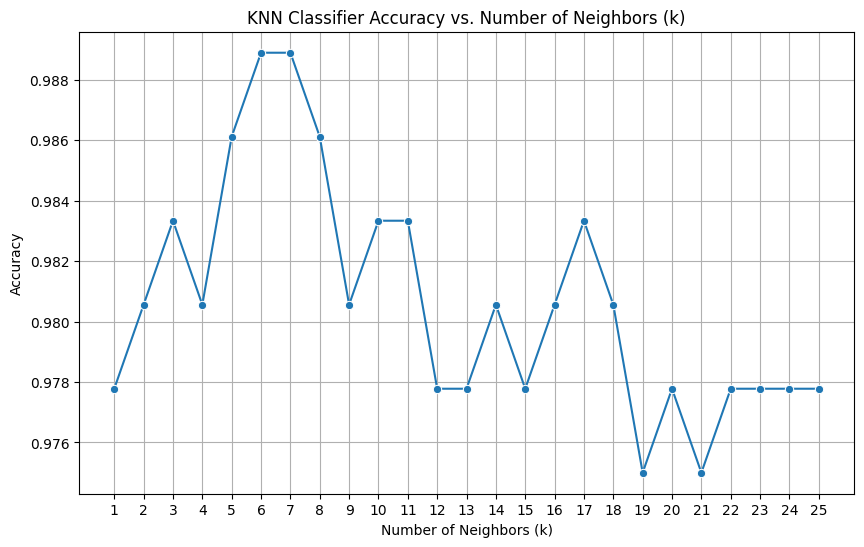

Best k: 6
Best Accuracy: 0.9889


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_train, X_test, y_train, y_test are already defined from the previous steps

# Perform KNN classification for a range of k values
k_values = range(1, 26) # Test k from 1 to 20
accuracies = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    y_pred_knn = knn_model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_knn))

# Plot the accuracy vs. k values
plt.figure(figsize=(10, 6))
sns.lineplot(x=list(k_values), y=accuracies, marker='o')
plt.title('KNN Classifier Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

# Find the best k and its accuracy
best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)
print(f"Best k: {best_k}")
print(f"Best Accuracy: {best_accuracy:.4f}")

In [ ]:
y_pred = model.predict(X_test)

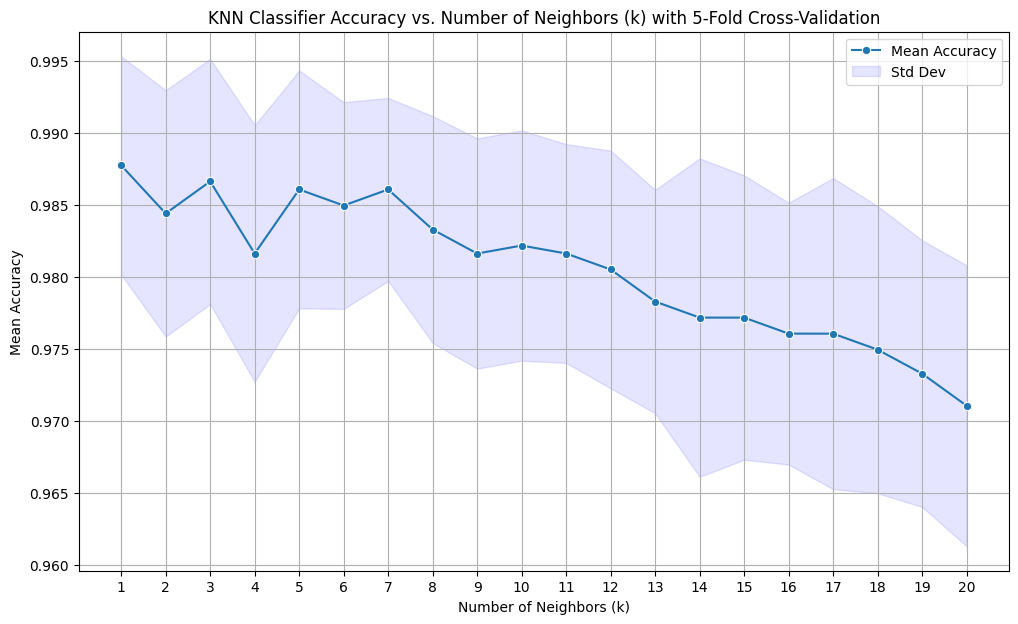

Best k from 5-fold cross-validation: 1
Highest Mean Accuracy: 0.9878


In [ ]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming digits.data and digits.target are available from previous steps
X = digits.data
y = digits.target

# Define a range of k values to test
k_values = range(1, 21)

# Number of folds for cross-validation
num_folds = 5 # You can change this value

# Prepare to store mean accuracies for each k
mean_accuracies = []
std_accuracies = []

# Initialize KFold cross-validator
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Perform k-fold cross-validation
    scores = cross_val_score(knn, X, y, cv=kf, scoring='accuracy')
    mean_accuracies.append(scores.mean())
    std_accuracies.append(scores.std())

# Plot the results
plt.figure(figsize=(12, 7))
sns.lineplot(x=list(k_values), y=mean_accuracies, marker='o', label='Mean Accuracy')
plt.fill_between(k_values, np.array(mean_accuracies) - np.array(std_accuracies),
                 np.array(mean_accuracies) + np.array(std_accuracies), color='blue', alpha=0.1, label='Std Dev')
plt.title(f'KNN Classifier Accuracy vs. Number of Neighbors (k) with {num_folds}-Fold Cross-Validation')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Accuracy')
plt.xticks(list(k_values))
plt.grid(True)
plt.legend()
plt.show()

# Find the best k value
best_k_cv = k_values[np.argmax(mean_accuracies)]
highest_accuracy_cv = np.max(mean_accuracies)

print(f"Best k from {num_folds}-fold cross-validation: {best_k_cv}")
print(f"Highest Mean Accuracy: {highest_accuracy_cv:.4f}")

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      1.00      1.00        30
           9       0.97      0.97      0.97        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360


Confusion Matrix:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 46  1  0  0  0]
 

Let's create a custom representation of the digit '7' based on the structure of the `digits` dataset (8x8 pixel values, flattened into a 64-feature array). We'll then use the trained `SVC` model to predict this custom digit.

In [ ]:
import numpy as np

# A custom representation of the digit '7' as an 8x8 array
# Pixel values range from 0 (white) to 16 (black)
custom_digit_7 = np.array([
    [ 0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0, 16, 16, 16, 16, 16,  0],
    [ 0,  0,  0,  0,  0,  0,  8,  0],
    [ 0,  0,  0,  0,  0,  4,  0,  0],
    [ 0,  0,  0,  0,  2,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0]
]).reshape(1, -1) # Reshape to (1, 64) for single sample prediction

print("Custom digit '7' data shape:", custom_digit_7.shape)

# Predict the custom digit using the trained model
predicted_digit = model.predict(custom_digit_7)

print(f"The predicted digit for the custom input is: {predicted_digit[0]}")

Custom digit '7' data shape: (1, 64)
The predicted digit for the custom input is: 9


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# A custom representation of the digit '9' as an 8x8 array
# Pixel values range from 0 (white) to 16 (black)
custom_digit_9 = np.array([
    [ 0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0, 16, 16,  0,  0],
    [ 0,  0,  0, 16,  0, 16,  0,  0],
    [ 0,  0, 16, 16, 16, 16,  0,  0],
    [ 0,  0,  0,  0, 16,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0]
]).reshape(1, -1) # Reshape to (1, 64) for single sample prediction

print("Custom digit '9' data shape:", custom_digit_9.shape)

# Predict the custom digit using the trained model
predicted_digit_9 = model.predict(custom_digit_9)

print(f"The predicted digit for the custom input is: {predicted_digit_9[0]}")

Custom digit '9' data shape: (1, 64)
The predicted digit for the custom input is: 4


In [ ]:
import numpy as np

# Generate some new synthetic data for prediction.
# Assuming the original digits data has 64 features (8x8 image flattened).
# Let's create 5 new random samples for demonstration.
num_new_samples = 5
num_features = digits.data.shape[1] # Should be 64 for digits dataset

# Generate random pixel values between 0 and 16, similar to the original data
new_data = np.random.randint(0, 17, size=(num_new_samples, num_features)).astype(float)

print("Generated new data samples (first 5 features shown):")
print(new_data[:, :5]) # Displaying first 5 features for brevity

Generated new data samples (first 5 features shown):
[[12.  0.  7. 13. 15.]
 [ 4.  3.  1.  9.  0.]
 [11.  8. 11.  8.  6.]
 [ 5.  5. 11. 12. 12.]
 [ 5.  2.  4.  4.  9.]]


In [ ]:
# Use the trained SVC model to predict on the new data
new_predictions = model.predict(new_data)

print("\nPredictions for the new data:")
print(new_predictions)

# Optional: Display the new data as images if desired (requires reshaping)
# This part is commented out but can be enabled if the user wants to visualize
# fig, axes = plt.subplots(1, num_new_samples, figsize=(num_new_samples * 2, 2))
# for i, ax in enumerate(axes):
#     ax.imshow(new_data[i].reshape(8, 8), cmap=plt.cm.gray_r, interpolation='nearest')
#     ax.set_title(f'Pred: {new_predictions[i]}')
#     ax.set_axis_off()
# plt.suptitle('New Data Samples and Their Predictions', y=1.02)
# plt.tight_layout()
# plt.show()


Predictions for the new data:
[1 1 1 7 1]


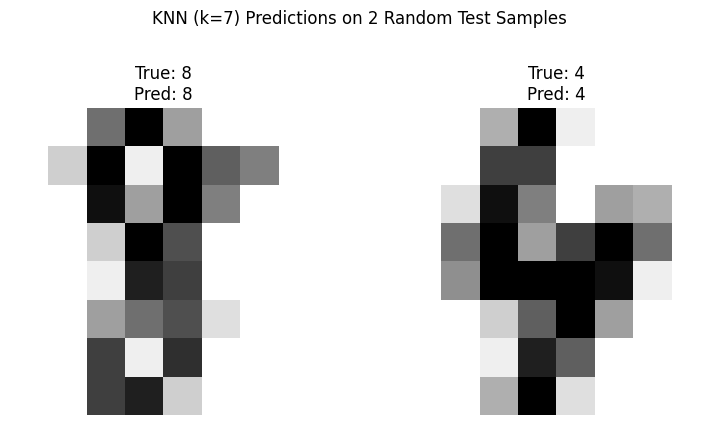

True labels for selected samples: [8 4]
Predicted labels for selected samples: [8 4]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# 1. Train a KNN model with k=7
knn_model_k7 = KNeighborsClassifier(n_neighbors=7)
knn_model_k7.fit(X_train, y_train)

# 2. Select 2 random samples from the testing data
np.random.seed(1) # for reproducibility
random_indices = np.random.choice(len(X_test), 2, replace=False)

sample_images = X_test[random_indices]
true_labels = y_test[random_indices]

# 3. Predict the classes of these 2 random samples
predicted_labels = knn_model_k7.predict(sample_images)

# 4. Plot the predicted values and compare with testing data
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i, ax in enumerate(axes):
    ax.imshow(sample_images[i].reshape(8, 8), cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}")
    ax.set_axis_off()

plt.suptitle(f'KNN (k=7) Predictions on 2 Random Test Samples', y=1.05)
plt.tight_layout()
plt.show()

print(f"True labels for selected samples: {true_labels}")
print(f"Predicted labels for selected samples: {predicted_labels}")